#### Student Performance Classification
Educational institutions increasingly rely on data-driven insights to understand the factors that influence students' academic outcomes. With the availability of digital learning platforms and institutional records, it has become possible to analyze student behavior, engagement, and socio-demographic characteristics to predict their academic performance more accurately.

This project aims to analyze students’ academic activities and related factors using the Students' Academic Performance Dataset and develop a machine learning–based classification model that can predict a student’s performance level. The dataset contains 480 student records with 13 original attributes, out of which 10 key features—representing academic behavior, learning engagement, parental involvement, and demographic information—are used for the analysis.

The primary goal of the study is to build a model that classifies students into one of the predefined performance categories under the ‘Class’ attribute:

* Low Performance
* Medium Performance
* High Performance

##### Data Description:  
1. Gender - Student's gender (Nominal: 'Male' or 'Female’)
2. Educational Stages - Educational level student belongs (Nominal: ‘lowerlevel’,’MiddleSchool’,’HighSchool’)
3. Section ID- Classroom student belongs (Nominal:’A’,’B’,’C’)
4. Relation - Parent responsible for the student (Nominal:’Mum’,’Father’)
5. Raised Hand - How many times the student raises his/her hand on the classroom (Numeric:0-100)
6. Visited Resources - How many times the student visits a course content(numeric:0-100)
7. Viewing Announcements - How many times the student checks the new announcements(numeric:0-100)
8. Discussion Groups - How many times the student participate in discussion groups (numeric:0-100)
9. Student Absence Days - The number of absence days for each student (nominal: above-7, under-7)
10. Class - Overall performance level student belongs (Nominal: 'H','M','L')


The students are classified into three numerical intervals based on their total grade/mark
* Low-Level: interval includes values from 0 to 69

* Middle-Level: interval includes values from 70 to 89

* High-Level: interval includes values from 90-100



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\USER\Downloads\xAPI-Edu-Data.csv")
data

,gender,StageID,SectionID,Relation,Semester,Topic,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,lowerlevel,A,Father,F,IT,15,16,2,20,Good,Under-7,M
1,M,lowerlevel,A,Father,F,IT,20,20,3,25,Good,Under-7,M
2,M,lowerlevel,A,Father,F,IT,10,7,0,30,Bad,Above-7,L
3,M,lowerlevel,A,Father,F,IT,30,25,5,35,Bad,Above-7,L
4,M,lowerlevel,A,Father,F,IT,40,50,12,50,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,F,MiddleSchool,A,Father,S,Chemistry,5,4,5,8,Bad,Above-7,L
476,F,MiddleSchool,A,Father,F,Geology,50,77,14,28,Bad,Under-7,M
477,F,MiddleSchool,A,Father,S,Geology,55,74,25,29,Bad,Under-7,M
478,F,MiddleSchool,A,Father,F,History,30,17,14,57,Bad,Above-7,L


In [3]:
data.describe(include="all")

,gender,StageID,SectionID,Relation,Semester,Topic,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
count,480,480,480,480,480,480,480.000000,480.000000,480.000000,480.000000,480,480,480
unique,2,3,3,2,2,12,NaN,NaN,NaN,NaN,2,2,3
top,M,MiddleSchool,A,Father,F,IT,NaN,NaN,NaN,NaN,Good,Under-7,M
freq,305,248,283,283,245,95,NaN,NaN,NaN,NaN,292,289,211
mean,NaN,NaN,NaN,NaN,NaN,NaN,46.775000,54.797917,37.918750,43.283333,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,30.779223,33.080007,26.611244,27.637735,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,15.750000,20.000000,14.000000,20.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,65.000000,33.000000,39.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,75.000000,84.000000,58.000000,70.000000,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   StageID                   480 non-null    object
 2   SectionID                 480 non-null    object
 3   Relation                  480 non-null    object
 4   Semester                  480 non-null    object
 5   Topic                     480 non-null    object
 6   raisedhands               480 non-null    int64 
 7   VisITedResources          480 non-null    int64 
 8   AnnouncementsView         480 non-null    int64 
 9   Discussion                480 non-null    int64 
 10  ParentschoolSatisfaction  480 non-null    object
 11  StudentAbsenceDays        480 non-null    object
 12  Class                     480 non-null    object
dtypes: int64(4), object(9)
memory usage: 48.9+ KB


In [5]:
data.isnull().sum()

gender                      0
StageID                     0
SectionID                   0
Relation                    0
Semester                    0
Topic                       0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [6]:
for i in data.columns:
    print({i:data[i].unique()})

{'gender': array(['M', 'F'], dtype=object)}
{'StageID': array(['lowerlevel', 'MiddleSchool', 'HighSchool'], dtype=object)}
{'SectionID': array(['A', 'B', 'C'], dtype=object)}
{'Relation': array(['Father', 'Mum'], dtype=object)}
{'Semester': array(['F', 'S'], dtype=object)}
{'Topic': array(['IT', 'Math', 'Arabic', 'Science', 'English', 'Quran', 'Spanish',
       'French', 'History', 'Biology', 'Chemistry', 'Geology'],
      dtype=object)}
{'raisedhands': array([ 15,  20,  10,  30,  40,  42,  35,  50,  12,  70,  19,   5,  62,
        36,  55,  69,  60,   2,   0,   8,  25,  75,   4,  45,  14,  33,
         7,  13,  29,  39,  49,  16,  28,  27,  21,  80,  17,  65,  22,
        11,   1,   3, 100,   6,  90,  77,  24,  66,  23,  82,  72,  51,
        85,  87,  95,  81,  53,  92,  83,  67,  96,  57,  73,   9,  32,
        52,  59,  61,  79,  18,  74,  97,  41,  71,  98,  78,  89,  88,
        86,  76,  99,  84])}
{'VisITedResources': array([16, 20,  7, 25, 50, 30, 12, 10, 21, 80, 88,  6,  1, 1

In [7]:
data.Topic.value_counts()

Topic
IT           95
French       65
Arabic       59
Science      51
English      45
Biology      30
Spanish      25
Geology      24
Chemistry    24
Quran        22
Math         21
History      19
Name: count, dtype: int64

In [8]:
data["Institute"] = "XYZ"
data

,gender,StageID,SectionID,Relation,Semester,Topic,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class,Institute
0,M,lowerlevel,A,Father,F,IT,15,16,2,20,Good,Under-7,M,XYZ
1,M,lowerlevel,A,Father,F,IT,20,20,3,25,Good,Under-7,M,XYZ
2,M,lowerlevel,A,Father,F,IT,10,7,0,30,Bad,Above-7,L,XYZ
3,M,lowerlevel,A,Father,F,IT,30,25,5,35,Bad,Above-7,L,XYZ
4,M,lowerlevel,A,Father,F,IT,40,50,12,50,Bad,Above-7,M,XYZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,F,MiddleSchool,A,Father,S,Chemistry,5,4,5,8,Bad,Above-7,L,XYZ
476,F,MiddleSchool,A,Father,F,Geology,50,77,14,28,Bad,Under-7,M,XYZ
477,F,MiddleSchool,A,Father,S,Geology,55,74,25,29,Bad,Under-7,M,XYZ
478,F,MiddleSchool,A,Father,F,History,30,17,14,57,Bad,Above-7,L,XYZ


### Feature Selection

In [9]:
data.columns

Index(['gender', 'StageID', 'SectionID', 'Relation', 'Semester', 'Topic',
       'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class', 'Institute'],
      dtype='object')

In [10]:
### Dropping institute columns as it has singularity
data.drop(["Institute"],axis=1,inplace=True)

In [11]:
data

,gender,StageID,SectionID,Relation,Semester,Topic,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,lowerlevel,A,Father,F,IT,15,16,2,20,Good,Under-7,M
1,M,lowerlevel,A,Father,F,IT,20,20,3,25,Good,Under-7,M
2,M,lowerlevel,A,Father,F,IT,10,7,0,30,Bad,Above-7,L
3,M,lowerlevel,A,Father,F,IT,30,25,5,35,Bad,Above-7,L
4,M,lowerlevel,A,Father,F,IT,40,50,12,50,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,F,MiddleSchool,A,Father,S,Chemistry,5,4,5,8,Bad,Above-7,L
476,F,MiddleSchool,A,Father,F,Geology,50,77,14,28,Bad,Under-7,M
477,F,MiddleSchool,A,Father,S,Geology,55,74,25,29,Bad,Under-7,M
478,F,MiddleSchool,A,Father,F,History,30,17,14,57,Bad,Above-7,L


In [12]:
# Dropping "SectionID","Semester" based on domain knowledge
data.drop(["SectionID","Semester"],axis=1,inplace=True)

In [13]:
data

,gender,StageID,Relation,Topic,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,lowerlevel,Father,IT,15,16,2,20,Good,Under-7,M
1,M,lowerlevel,Father,IT,20,20,3,25,Good,Under-7,M
2,M,lowerlevel,Father,IT,10,7,0,30,Bad,Above-7,L
3,M,lowerlevel,Father,IT,30,25,5,35,Bad,Above-7,L
4,M,lowerlevel,Father,IT,40,50,12,50,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...
475,F,MiddleSchool,Father,Chemistry,5,4,5,8,Bad,Above-7,L
476,F,MiddleSchool,Father,Geology,50,77,14,28,Bad,Under-7,M
477,F,MiddleSchool,Father,Geology,55,74,25,29,Bad,Under-7,M
478,F,MiddleSchool,Father,History,30,17,14,57,Bad,Above-7,L


In [14]:
# Dropping feature "Topic" on the basis of domain knowledge & high cardinality
data.drop("Topic",axis=1,inplace=True)

In [15]:
data

,gender,StageID,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,lowerlevel,Father,15,16,2,20,Good,Under-7,M
1,M,lowerlevel,Father,20,20,3,25,Good,Under-7,M
2,M,lowerlevel,Father,10,7,0,30,Bad,Above-7,L
3,M,lowerlevel,Father,30,25,5,35,Bad,Above-7,L
4,M,lowerlevel,Father,40,50,12,50,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...
475,F,MiddleSchool,Father,5,4,5,8,Bad,Above-7,L
476,F,MiddleSchool,Father,50,77,14,28,Bad,Under-7,M
477,F,MiddleSchool,Father,55,74,25,29,Bad,Under-7,M
478,F,MiddleSchool,Father,30,17,14,57,Bad,Above-7,L


### EDA

In [16]:
data.dtypes

gender                      object
StageID                     object
Relation                    object
raisedhands                  int64
VisITedResources             int64
AnnouncementsView            int64
Discussion                   int64
ParentschoolSatisfaction    object
StudentAbsenceDays          object
Class                       object
dtype: object

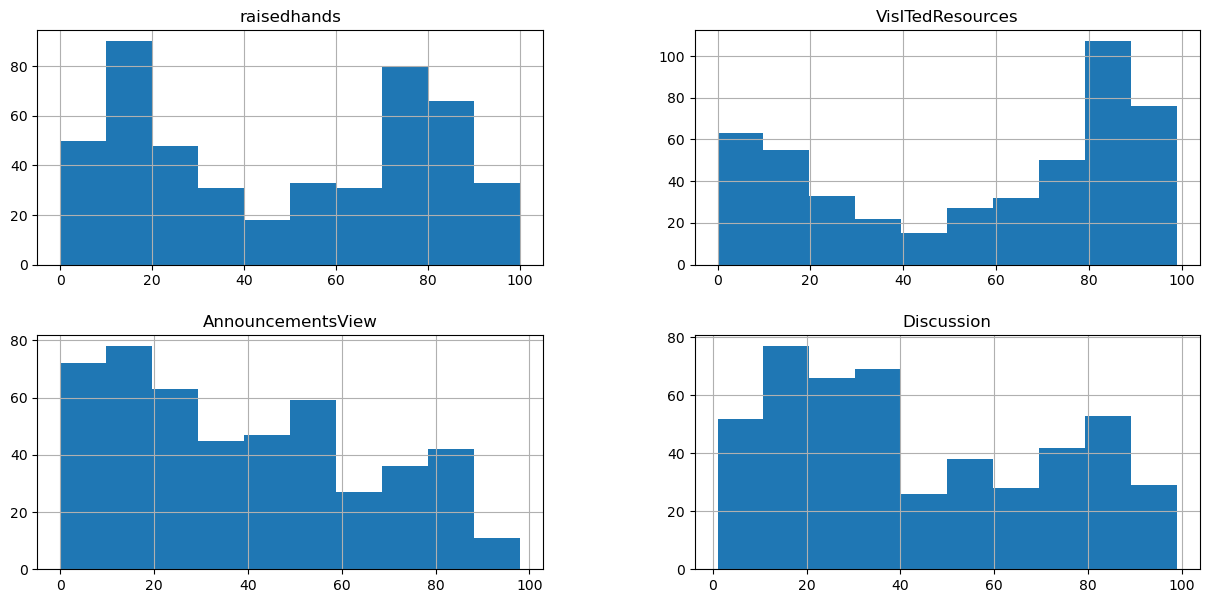

In [17]:
# Histograms helps to understand the frequency distribution of Single continous numeric feature
data.hist(figsize=(15, 7));

In the above histogram, X-axis defines the frequency number of a student's activity on a particular attribute  
and Y-axis defines the count. The histogram shows that -

1. Majority students perform visiting resources.
2. Majority of the students are less eager to view Announcements & to Discuss in Groups.
3. An average situation arises in case of the hand raising. It seems students have a mixed interest in raising the hand in class.

In [18]:
data.columns

Index(['gender', 'StageID', 'Relation', 'raisedhands', 'VisITedResources',
       'AnnouncementsView', 'Discussion', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [19]:
features = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

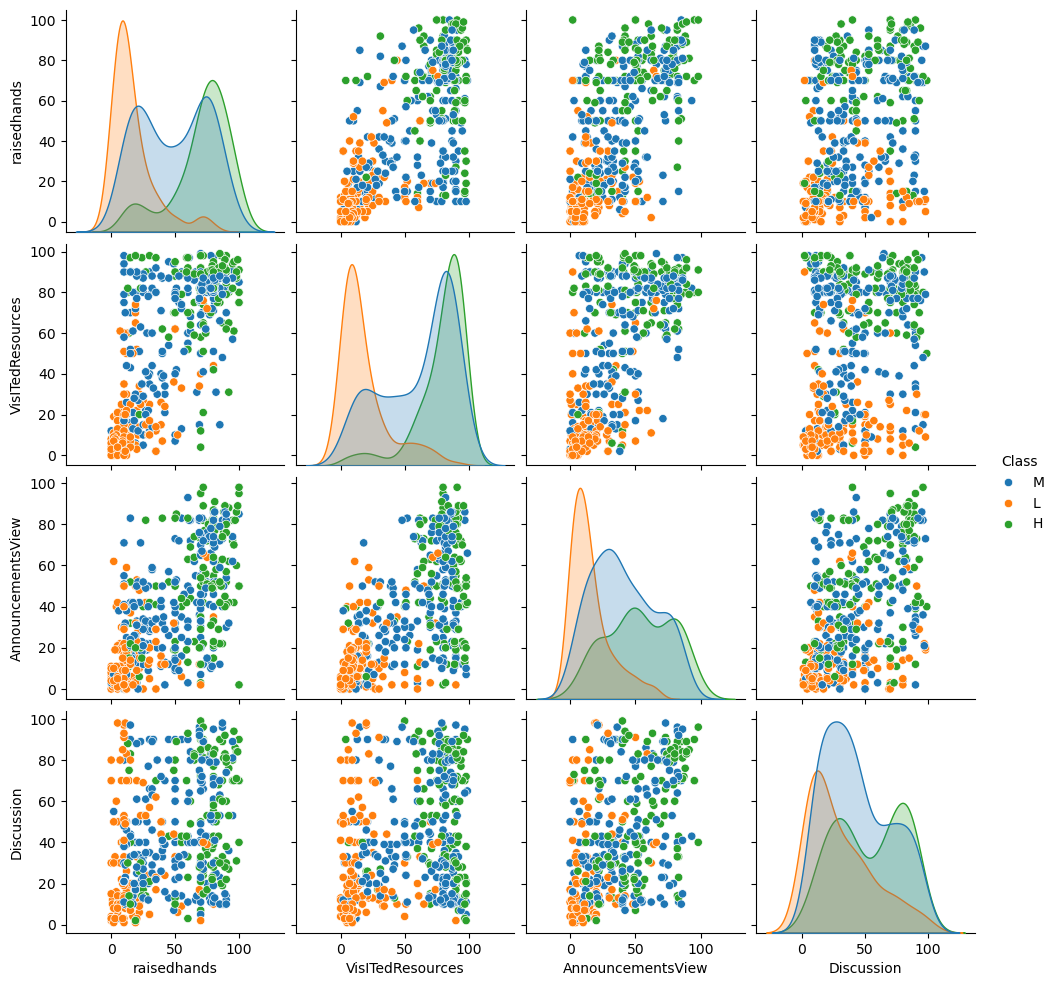

In [20]:
sns.pairplot(x_vars = features, y_vars=features,data=data,hue="Class");

From the above pair plot, it is quite a lot clear to see that High and Low-level students are distinguishable in every combination  
of pair plot but Medium level students are scattered in almost everywhere and mixed up both High and Low-level students.

#### Visualization of catagorical data

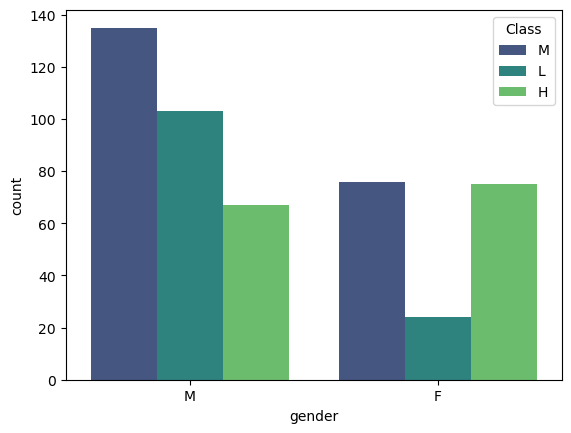

In [21]:
sns.countplot(data=data,x='gender',hue="Class",palette='viridis');

Though the number of male students is greater than the female but the percentage of High-level students are less than female students.   
On the other hand, low-level students in the male are quite a lot greater than the female students.

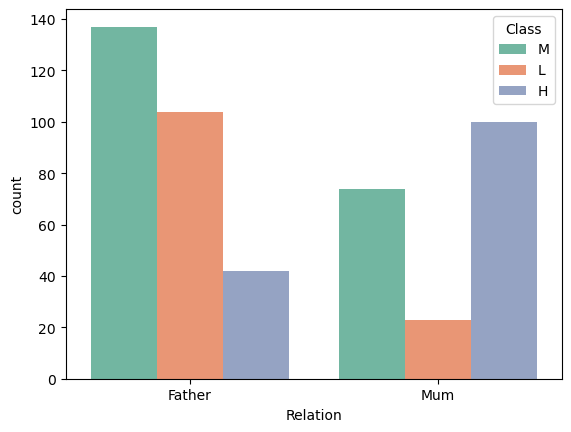

In [22]:
sns.countplot(data=data,x='Relation',hue='Class',palette='Set2');

It seems to have a relation with Mum has a very much positive impact on students performance

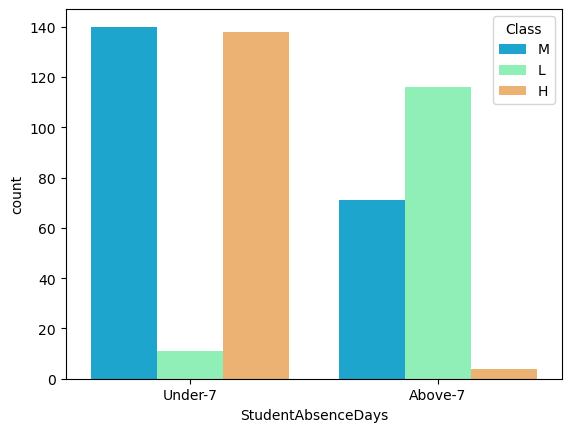

In [23]:
sns.countplot(data=data,x='StudentAbsenceDays',hue='Class',palette='rainbow');

The above picture clearly states that the student who is absent less than 7 days is mostly the successful one.   
It means students absence has a high impact on their overall performance.

In [24]:
data.isnull().sum()

gender                      0
StageID                     0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [25]:
data.Class.value_counts()

Class
M    211
H    142
L    127
Name: count, dtype: int64

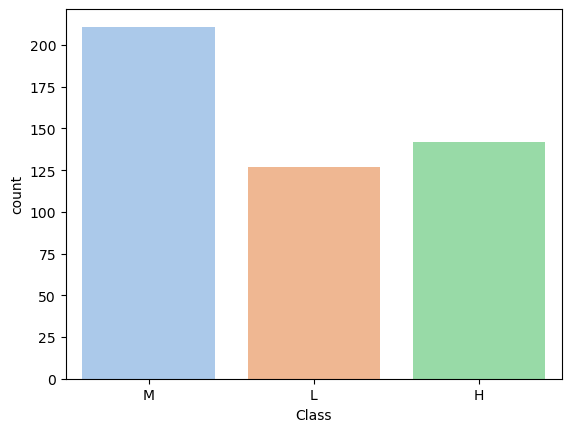

In [26]:
import warnings
warnings.filterwarnings("ignore")
sns.countplot(data=data,x="Class",palette = "pastel");

In [27]:
colname=[]
for x in data.columns:
    if data[x].dtype=='object':
        colname.append(x)
colname

['gender',
 'StageID',
 'Relation',
 'ParentschoolSatisfaction',
 'StudentAbsenceDays',
 'Class']

In [28]:
colname[:-1]

['gender',
 'StageID',
 'Relation',
 'ParentschoolSatisfaction',
 'StudentAbsenceDays']

In [29]:
# For preprocessing the data
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for x in colname[:-1]:
    data[x]=le.fit_transform(data[x])

    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print('Feature', x)
    print('mapping', le_name_mapping)
    print('-----------------------')


Feature gender
mapping {'F': np.int64(0), 'M': np.int64(1)}
-----------------------
Feature StageID
mapping {'HighSchool': np.int64(0), 'MiddleSchool': np.int64(1), 'lowerlevel': np.int64(2)}
-----------------------
Feature Relation
mapping {'Father': np.int64(0), 'Mum': np.int64(1)}
-----------------------
Feature ParentschoolSatisfaction
mapping {'Bad': np.int64(0), 'Good': np.int64(1)}
-----------------------
Feature StudentAbsenceDays
mapping {'Above-7': np.int64(0), 'Under-7': np.int64(1)}
-----------------------


In [30]:
data

,gender,StageID,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,2,0,15,16,2,20,1,1,M
1,1,2,0,20,20,3,25,1,1,M
2,1,2,0,10,7,0,30,0,0,L
3,1,2,0,30,25,5,35,0,0,L
4,1,2,0,40,50,12,50,0,0,M
...,...,...,...,...,...,...,...,...,...,...
475,0,1,0,5,4,5,8,0,0,L
476,0,1,0,50,77,14,28,0,1,M
477,0,1,0,55,74,25,29,0,1,M
478,0,1,0,30,17,14,57,0,0,L


In [31]:
data.Class.unique()

array(['M', 'L', 'H'], dtype=object)

In [32]:
# Class follow an Ordinal approach for classes so we will try to encode it manually
data["Class"] = data["Class"].map({"L":0,"M":1,"H":2})

In [33]:
data

,gender,StageID,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,2,0,15,16,2,20,1,1,1
1,1,2,0,20,20,3,25,1,1,1
2,1,2,0,10,7,0,30,0,0,0
3,1,2,0,30,25,5,35,0,0,0
4,1,2,0,40,50,12,50,0,0,1
...,...,...,...,...,...,...,...,...,...,...
475,0,1,0,5,4,5,8,0,0,0
476,0,1,0,50,77,14,28,0,1,1
477,0,1,0,55,74,25,29,0,1,1
478,0,1,0,30,17,14,57,0,0,0


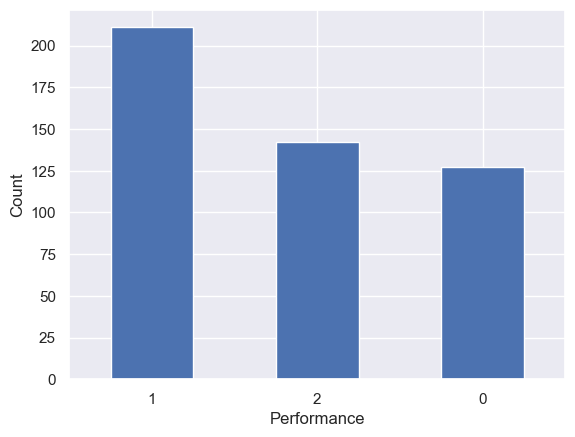

In [34]:
sns.set()
Class_plot=data['Class'].value_counts().plot(kind='bar')
plt.xlabel('Performance')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

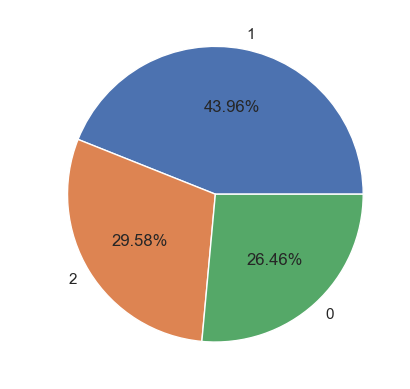

In [35]:
data['Class'].value_counts().plot(kind='pie',autopct="%.2f%%")
plt.ylabel(" ");

In [36]:
X = data.values[:,0:-1]  # 0 to -2
Y = data.values[:,-1]

In [37]:
print(X.shape)
print(Y.shape)

(480, 9)
(480,)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)
X = scaler.transform(X)
#X=scaler.fit_transform(X)
#print(X)

In [39]:
from sklearn.model_selection import train_test_split

#Split the data into test and train
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,
                                                    random_state=10)

In [40]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(384, 9)
(384,)
(96, 9)
(96,)


In [41]:
from sklearn.linear_model import LogisticRegression
#create a model
classifier=LogisticRegression()
#fitting training data to the model
classifier.fit(X_train,Y_train)

Y_pred=classifier.predict(X_test)
print(Y_pred)

[2 1 1 0 2 2 2 2 1 0 1 1 2 1 1 2 0 2 1 1 0 1 1 1 1 0 2 2 1 2 2 2 0 2 1 0 1
 1 0 2 1 0 1 0 1 2 2 1 1 2 1 0 2 1 1 2 2 0 1 2 2 0 2 1 1 1 1 1 0 2 1 0 1 1
 1 1 0 0 2 2 0 2 0 0 1 2 1 2 2 1 2 0 1 1 2 1]


In [42]:
np.set_printoptions(suppress= True)
Y_pred_prob=classifier.predict_proba(X_test)
Y_pred_prob

array([[0.00591701, 0.49434748, 0.4997355 ],
       [0.07064708, 0.85718398, 0.07216894],
       [0.14959046, 0.83346317, 0.01694638],
       [0.62906019, 0.36218993, 0.00874988],
       [0.00640642, 0.42250288, 0.5710907 ],
       [0.0002327 , 0.18604789, 0.8137194 ],
       [0.00302356, 0.29726439, 0.69971205],
       [0.00130094, 0.39139404, 0.60730502],
       [0.49239611, 0.50170139, 0.00590249],
       [0.95449583, 0.04530733, 0.00019684],
       [0.00138427, 0.62889304, 0.36972269],
       [0.37392422, 0.59124773, 0.03482805],
       [0.00499555, 0.48078095, 0.5142235 ],
       [0.07371507, 0.66428315, 0.26200178],
       [0.01197596, 0.71350876, 0.27451528],
       [0.00390199, 0.48539436, 0.51070365],
       [0.95306231, 0.04661094, 0.00032674],
       [0.00145996, 0.30853298, 0.69000706],
       [0.01196655, 0.87625951, 0.11177394],
       [0.00395981, 0.59754493, 0.39849525],
       [0.85182308, 0.14740519, 0.00077173],
       [0.00263395, 0.84556788, 0.15179817],
       [0.

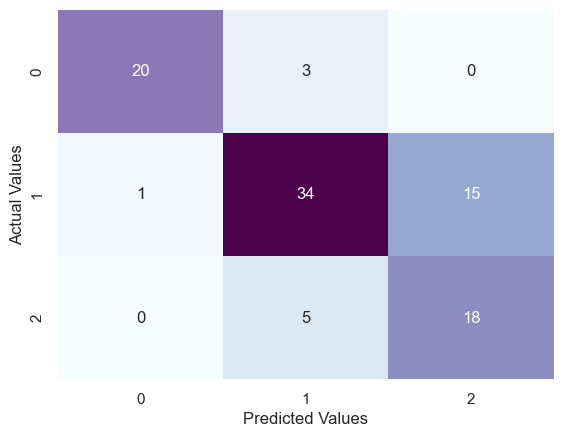

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91        23
           1       0.81      0.68      0.74        50
           2       0.55      0.78      0.64        23

    accuracy                           0.75        96
   macro avg       0.77      0.78      0.76        96
weighted avg       0.78      0.75      0.76        96

Accuracy of the model:  0.75


In [43]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()


print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [44]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(classifier.score(X_test, Y_test)))

Training set score: 0.7578
Test set score: 0.7500


In [45]:
#predicting using the Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion="gini",random_state=10)

#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)

Y_pred = model_DecisionTree.predict(X_test)
#print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

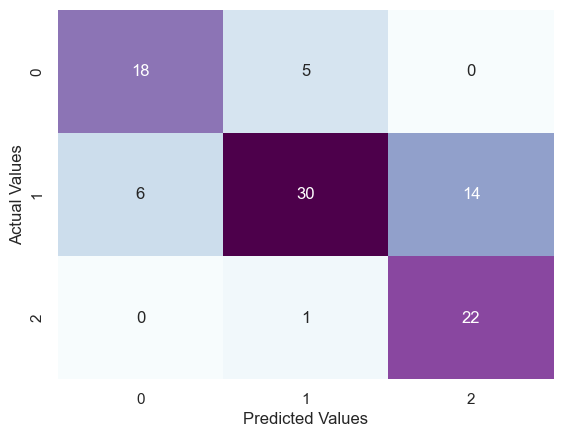

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.77        23
           1       0.83      0.60      0.70        50
           2       0.61      0.96      0.75        23

    accuracy                           0.73        96
   macro avg       0.73      0.78      0.74        96
weighted avg       0.76      0.73      0.73        96

Accuracy of the model:  0.7291666666666666


In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [47]:
model_DecisionTree.score(X_train,Y_train)

0.9973958333333334

In [48]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_DecisionTree.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_DecisionTree.score(X_test, Y_test)))

Training set score: 0.9974
Test set score: 0.7292


In [49]:
print(list(zip(data.columns[0:-1],model_DecisionTree.feature_importances_)))

[('gender', np.float64(0.04659080790408169)), ('StageID', np.float64(0.04475200367782753)), ('Relation', np.float64(0.03782980354869803)), ('raisedhands', np.float64(0.14128705922993948)), ('VisITedResources', np.float64(0.24978949957398358)), ('AnnouncementsView', np.float64(0.15716733396986007)), ('Discussion', np.float64(0.0922586971116643)), ('ParentschoolSatisfaction', np.float64(0.014873042610268889)), ('StudentAbsenceDays', np.float64(0.21545175237367642))]


In [50]:
data.columns

Index(['gender', 'StageID', 'Relation', 'raisedhands', 'VisITedResources',
       'AnnouncementsView', 'Discussion', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [51]:
sample=pd.DataFrame()

sample["Column"]=data.columns[0:-1]
sample["Imp value"]=model_DecisionTree.feature_importances_

sample.sort_values("Imp value",ascending=False)

,Column,Imp value
4,VisITedResources,0.249789
8,StudentAbsenceDays,0.215452
5,AnnouncementsView,0.157167
3,raisedhands,0.141287
6,Discussion,0.092259
0,gender,0.046591
1,StageID,0.044752
2,Relation,0.037830
7,ParentschoolSatisfaction,0.014873


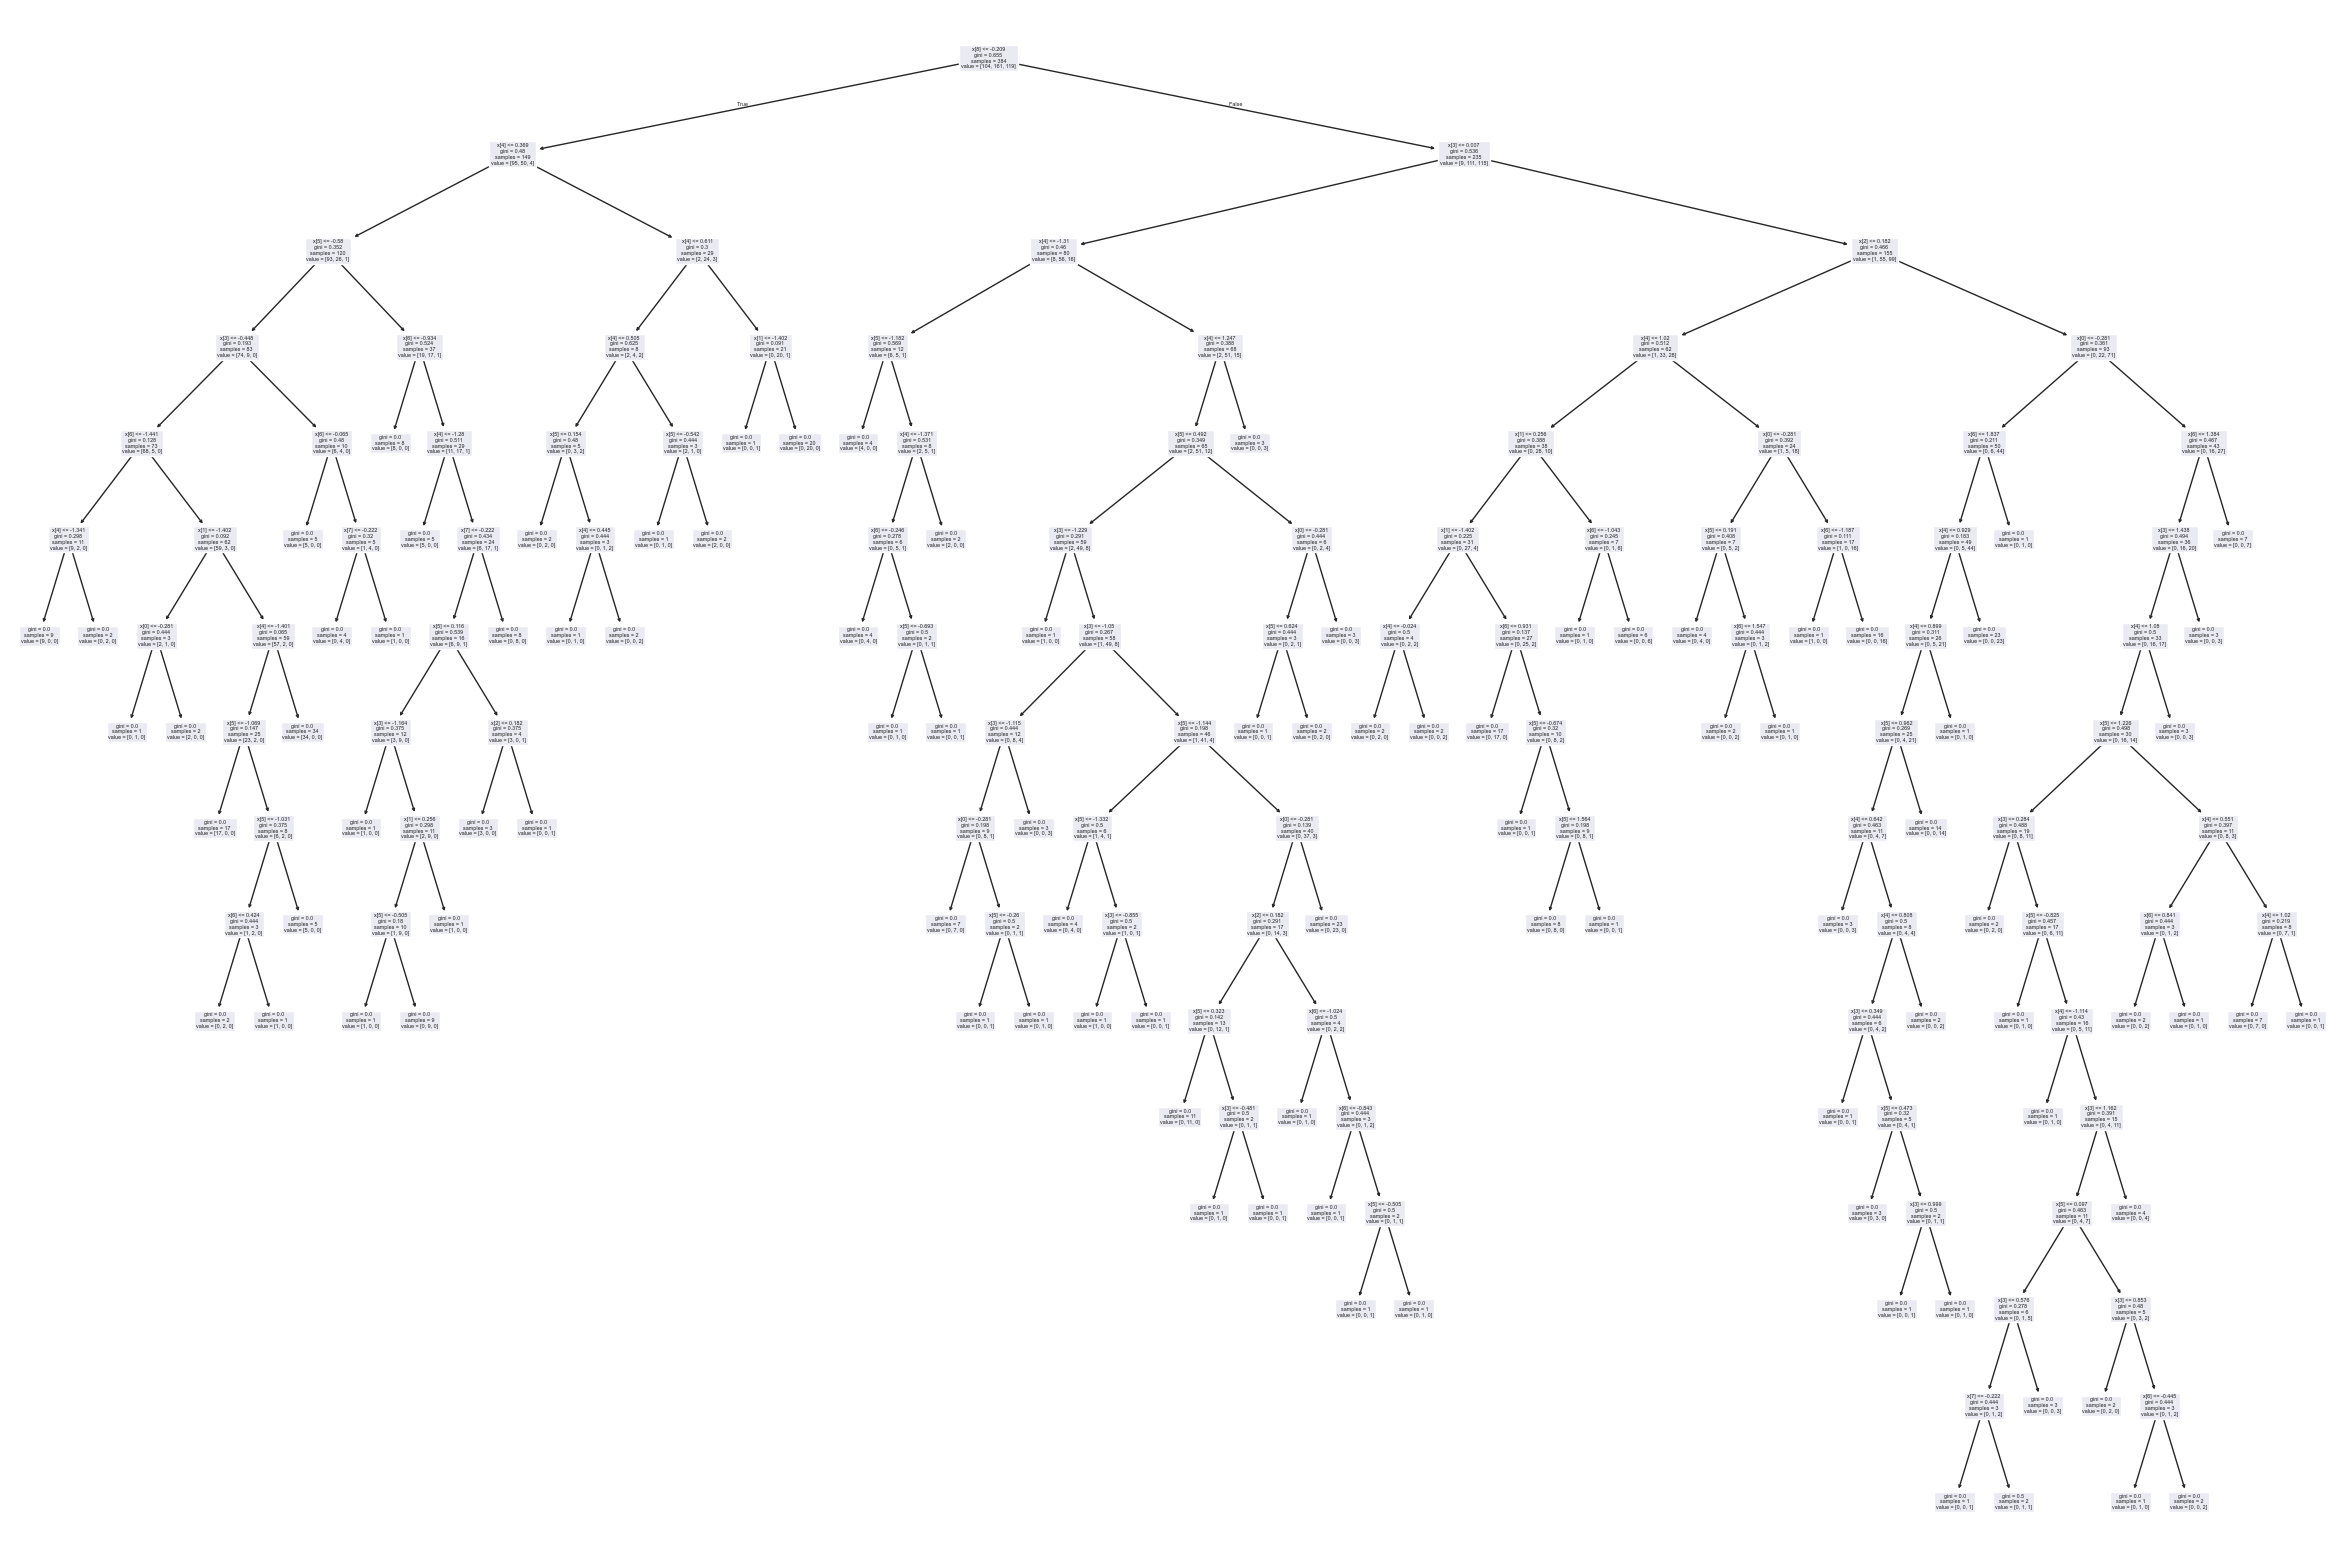

In [52]:
plt.figure(figsize=(30,20))

from sklearn import tree

tree.plot_tree(model_DecisionTree.fit(X_train, Y_train));

In [53]:
from sklearn import tree
with open(r"model_DecisionTree.txt", "w") as f:

    f = tree.export_graphviz(model_DecisionTree, feature_names=data.columns[0:-1],
                             out_file=f)

#generate the file and upload the code in webgraphviz.com to plot the decision tree

In [54]:
import os
os.getcwd()

'C:\\Users\\USER\\Desktop\\PGA 39'

In [55]:
### Utilizing results from feature importances for the model tuning
data_new = data.drop(["StageID","ParentschoolSatisfaction","Relation"],axis=1)
data_new

,gender,raisedhands,VisITedResources,AnnouncementsView,Discussion,StudentAbsenceDays,Class
0,1,15,16,2,20,1,1
1,1,20,20,3,25,1,1
2,1,10,7,0,30,0,0
3,1,30,25,5,35,0,0
4,1,40,50,12,50,0,1
...,...,...,...,...,...,...,...
475,0,5,4,5,8,0,0
476,0,50,77,14,28,1,1
477,0,55,74,25,29,1,1
478,0,30,17,14,57,0,0


In [56]:
# Splitting the data
X_n = data_new.values[:,:-1]
Y_n = data_new.values[:,-1]

In [57]:
print(X_n.shape)
print(Y_n.shape)

(480, 6)
(480,)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_n)
X_n = scaler.transform(X_n)
#X=scaler.fit_transform(X)
#print(X)

In [59]:
from sklearn.model_selection import train_test_split

#Split the data into test and train
X_train, X_test, Y_train, Y_test = train_test_split(X_n, Y_n, test_size=0.2,
                                                    random_state=42)

In [60]:
#predicting using the Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion="gini",random_state=30)

#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)

Y_pred = model_DecisionTree.predict(X_test)
#print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

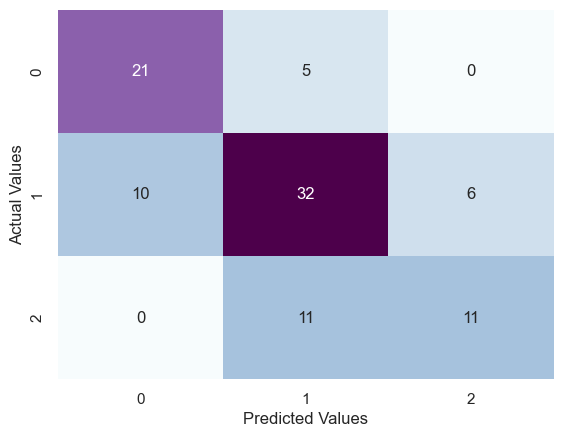

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.81      0.74        26
           1       0.67      0.67      0.67        48
           2       0.65      0.50      0.56        22

    accuracy                           0.67        96
   macro avg       0.66      0.66      0.66        96
weighted avg       0.67      0.67      0.66        96

Accuracy of the model:  0.6666666666666666


In [61]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

### Overfitting in Decision Tree algorithm
Overfitting is a practical problem while building a Decision-Tree model. The problem of overfitting is considered when the algorithm continues to go deeper and deeper to reduce the training-set error but results with an increased test-set error. So, accuracy of prediction for our model goes down. It generally happens when we build many branches due to outliers and irregularities in data.

Two approaches which can be used to avoid overfitting are as follows:-

* Pre-Pruning

* Post-Pruning

**Pre-Pruning**  
In pre-pruning, we stop the tree construction a bit early. We prefer not to split a node if its goodness measure is below a threshold value. But it is difficult to choose an appropriate stopping point.

**Post-Pruning**  
In post-pruning, we go deeper and deeper in the tree to build a complete tree. If the tree shows the overfitting problem then pruning is done as a post-pruning step. We use the cross-validation data to check the effect of our pruning. Using cross-validation data, we test whether expanding a node will result in improve or not. If it shows an improvement, then we can continue by expanding that node. But if it shows a reduction in accuracy then it should not be expanded. So, the node should be converted to a leaf node.

In [62]:
#predicting using the Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion="gini",random_state=20,
                                           splitter="best",min_samples_leaf=6,
                                           max_depth=15)

#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)

Y_pred = model_DecisionTree.predict(X_test)
#print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

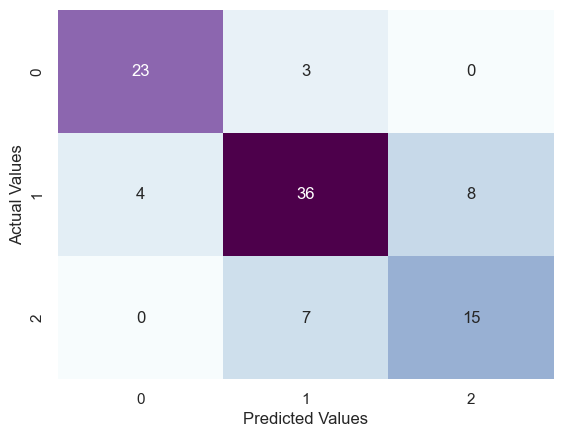

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        26
           1       0.78      0.75      0.77        48
           2       0.65      0.68      0.67        22

    accuracy                           0.77        96
   macro avg       0.76      0.77      0.77        96
weighted avg       0.77      0.77      0.77        96

Accuracy of the model:  0.7708333333333334


In [63]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [64]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_DecisionTree.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_DecisionTree.score(X_test, Y_test)))

Training set score: 0.8307
Test set score: 0.7708


In [65]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier

model_RandomForest=RandomForestClassifier(n_estimators=100,
                                          random_state=10, bootstrap=True)

#fit the model on the data and predict the values
model_RandomForest.fit(X_train,Y_train)

Y_pred=model_RandomForest.predict(X_test)

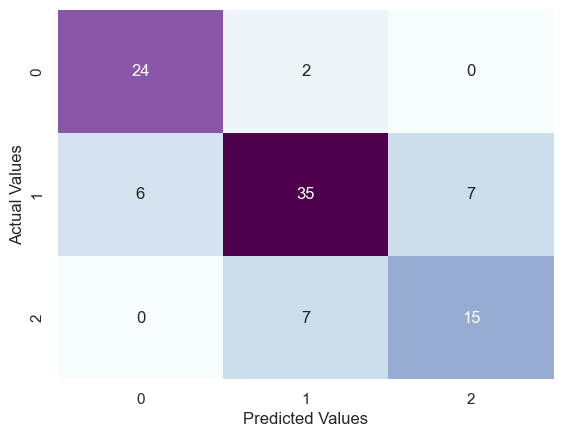

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        26
           1       0.80      0.73      0.76        48
           2       0.68      0.68      0.68        22

    accuracy                           0.77        96
   macro avg       0.76      0.78      0.77        96
weighted avg       0.77      0.77      0.77        96

Accuracy of the model:  0.7708333333333334


In [66]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [67]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_RandomForest.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_RandomForest.score(X_test, Y_test)))

Training set score: 0.9974
Test set score: 0.7708


In [68]:
model_RandomForest=RandomForestClassifier( random_state=10, bootstrap=True) #fixed parameters should be passsed here

#parameters for trial and error should be passed here
parameter_space = {
    'n_estimators':[100,300,500,1000],       
    'max_depth':[10,15,8, 12],
    'min_samples_leaf':[1,3,4,5,6,7]
    }
from sklearn.model_selection import RandomizedSearchCV #RandomizedSearchCV
clf = RandomizedSearchCV(model_RandomForest, parameter_space, cv=5)

In [69]:
clf.fit(X_train,Y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=10),
                   param_distributions={'max_depth': [10, 15, 8, 12],
                                        'min_samples_leaf': [1, 3, 4, 5, 6, 7],
                                        'n_estimators': [100, 300, 500, 1000]})

In [70]:
print('Best parameters found:\n', clf.best_params_)

Best parameters found:
 {'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 12}


In [71]:
clf.best_score_

np.float64(0.7368421052631579)

In [72]:
Y_pred=clf.predict(X_test)

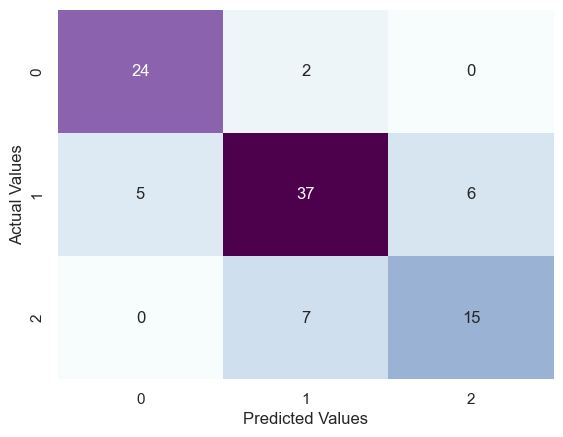

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        26
           1       0.80      0.77      0.79        48
           2       0.71      0.68      0.70        22

    accuracy                           0.79        96
   macro avg       0.78      0.79      0.79        96
weighted avg       0.79      0.79      0.79        96

Accuracy of the model:  0.7916666666666666


In [73]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [74]:
clf.score(X_train,Y_train)

0.8854166666666666

### Handling Imbalanced Data

Class Imbalance occurs when most data belong to one class or when the distribution of samples across the known classes is biased or skewed.  
If a dataset have positive and negative target, in case of class imbalance the total number of a positive class of data is far less than the total number of negative class of data.  

For example, when target belongs to two classes “Yes” and “No” and 90% of data belong to “Yes” class.

Class imbalance occurs in two-class classification problems as well as multi-class classification problems.

### How Imbalanced is the data?
balanced_accuracy_score : The balanced accuracy in binary and multiclass classification problems is to deal with imbalanced datasets.It is defined as the average of recall obtained on each class.The best value is 1 and the worst value is 0.

accuracy_score : It is known as Accuracy classification score. In multilabel classification, this function computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

For balanced dataset the balanced_accuracy_score becomes equivalent to the accuracy_score.

### Impact of Class Imbalance Data
Most machine learning algorithms assume data equally distributed. So, when we have a class imbalance, the machine learning classifier tends to be more biased towards the majority class, causing bad classification of the minority class. A major issue in the classification of class imbalanced datasets involves the determination of the most suitable performance metrics to be used.  

Conventional algorithms are often biased towards the majority class because their loss functions attempt to optimize quantities such as error rate, not taking the data distribution into consideration. In the worst case, minority class are treated as outliers of the majority class and ignored. The learning algorithm simply generates a trivial classifier that classifies every example as the majority class.

### How to Handle Imbalanced Classes?

1. Changing Performance Metric :

For a classification problem, the performance is mainly figured out by using classification accuracy. For high imbalance class, the model will predict the value of the majority class for all predictions and achieve a high classification accuracy. But this model is not useful in the problem domain. This is called the Accuracy Paradox. To overcome this, other performance metric is to be considered for evaluation, we can use confusion matrix, precision, recall and F1 score.

* Confusion Matrix: a table showing correct predictions and types of incorrect predictions

* Precision: the number of true positives divided by all positive predictions. Precision is also called Positive Predictive Value. It is a measure of a classifier’s exactness. Low precision indicates a high number of false positives.

* Recall: the number of true positives divided by the number of positive values in the test data. Recall is also called Sensitivity or the True Positive Rate. It is a measure of a classifier’s completeness. Low recall indicates a high number of false negatives.

* F1 Score: the weighted average of precision and recall.

2. Resampling

Resampling consist of -

* Under sampling of the majority class: This technique involves removing random records from the majority class, which can cause loss of information. This could lead to underfitting and poor generalization to the test set.
* Oversampling of the minority class: Adding more examples from the minority class. The simplest implementation of over-sampling is to duplicate random records from the minority class, which can cause overfitting.

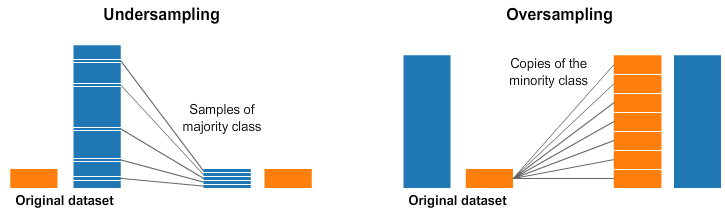  

3. SMOTE (Synthetic Minority Over-sampling Technique):

An oversampling technique that generates synthetic samples from the minority class. SMOTE works by utilizing a k-nearest neighbor algorithm to create synthetic data. SMOTE first start by choosing random data from the minority class, then k-nearest neighbors from the data are set. Depending upon the amount of over-sampling required, neighbors from the k nearest neighbors are randomly chosen. The synthetic points are added between the chosen point and its neighbors. It can be used when we can both classes can be seperated easily.
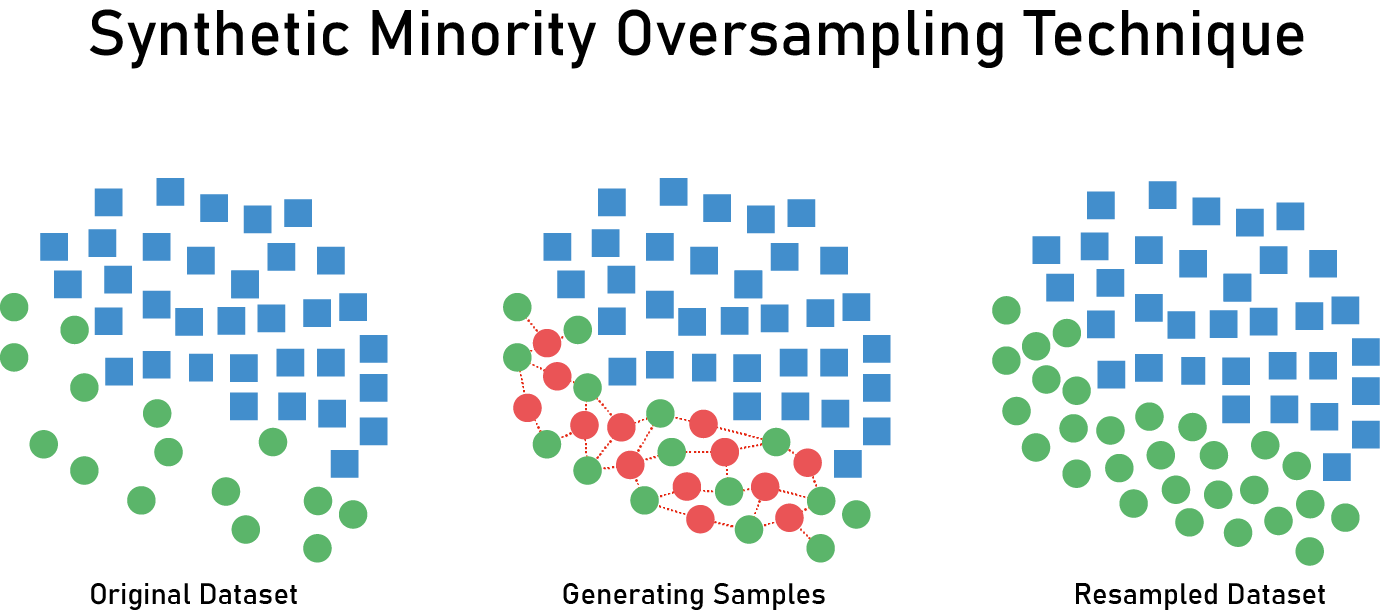